In [177]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
import matplotlib.pyplot as plt

dt_quejas = pd.read_csv('..\data\quejas-clientes.csv')
dt_quejas.head()

,Unnamed: 0,Complaint ID,Product,Sub-product,Issue,Sub-issue,State,ZIP code,Date received,Date sent to company,Company,Company response,Timely response?,Consumer disputed?
0,0,1291006,Debt collection,NaN,Communication tactics,Frequent or repeated calls,TX,76119.0,2015-03-19,2015-03-19,"Premium Asset Services, LLC",In progress,Yes,NaN
1,1,1290580,Debt collection,Medical,Cont'd attempts collect debt not owed,Debt is not mine,TX,77479.0,2015-03-19,2015-03-19,Accounts Receivable Consultants Inc.,Closed with explanation,Yes,NaN
2,2,1290564,Mortgage,FHA mortgage,"Application, originator, mortgage broker",NaN,MA,2127.0,2015-03-19,2015-03-19,RBS Citizens,Closed with explanation,Yes,Yes
3,3,1291615,Credit card,NaN,Other,NaN,CA,92592.0,2015-03-19,2015-03-19,Navy FCU,In progress,Yes,NaN
4,4,1292165,Debt collection,Non-federal student loan,Cont'd attempts collect debt not owed,Debt resulted from identity theft,NaN,43068.0,2015-03-19,2015-03-19,Transworld Systems Inc.,In progress,Yes,NaN


In [178]:
dt_quejas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28156 entries, 0 to 28155
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            28156 non-null  int64  
 1   Complaint ID          28156 non-null  int64  
 2   Product               28156 non-null  object 
 3   Sub-product           17582 non-null  object 
 4   Issue                 28154 non-null  object 
 5   Sub-issue             13211 non-null  object 
 6   State                 27735 non-null  object 
 7   ZIP code              27876 non-null  float64
 8   Date received         28156 non-null  object 
 9   Date sent to company  28156 non-null  object 
 10  Company               28156 non-null  object 
 11  Company response      28156 non-null  object 
 12  Timely response?      28156 non-null  object 
 13  Consumer disputed?    6006 non-null   object 
dtypes: float64(1), int64(2), object(11)
memory usage: 3.0+ MB


In [179]:
dt_quejas_corr = dt_quejas.drop(columns=['Unnamed: 0'])
dt_quejas_corr['Consumer disputed?'] = dt_quejas_corr['Consumer disputed?'].fillna('No')
dt_quejas_corr['ZIP code'] = dt_quejas_corr['ZIP code'].fillna('Unknown').astype(str).str.replace('.0', '', regex=False)
dt_quejas_corr['Sub-product'] = dt_quejas_corr['Sub-product'].fillna('Unknown')
dt_quejas_corr['Issue'] = dt_quejas_corr['Issue'].fillna('Other')
dt_quejas_corr['Sub-issue'] = dt_quejas_corr['Sub-issue'].fillna('Unknown')


dt_quejas_corr.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28156 entries, 0 to 28155
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Complaint ID          28156 non-null  int64 
 1   Product               28156 non-null  object
 2   Sub-product           28156 non-null  object
 3   Issue                 28156 non-null  object
 4   Sub-issue             28156 non-null  object
 5   State                 27735 non-null  object
 6   ZIP code              28156 non-null  object
 7   Date received         28156 non-null  object
 8   Date sent to company  28156 non-null  object
 9   Company               28156 non-null  object
 10  Company response      28156 non-null  object
 11  Timely response?      28156 non-null  object
 12  Consumer disputed?    28156 non-null  object
dtypes: int64(1), object(12)
memory usage: 2.8+ MB


In [180]:
dt_quejas_corr['State'].head(50)

0      TX
1      TX
2      MA
3      CA
4     NaN
5      OH
6      OH
7      CA
8      NJ
9      TX
10     ND
11     RI
12     CO
13     TX
14     UT
15     AL
16     PA
17     TX
18     CA
19     NY
20     NC
21     GA
22     IL
23     CA
24     WI
25     IL
26     MI
27     FL
28     FL
29     CA
30     CT
31     OR
32     GA
33     CA
34     VA
35     WA
36     WA
37     PA
38     TN
39     AL
40     MI
41     WI
42     PA
43     IL
44     MD
45     FL
46     IA
47     CA
48     MI
49     FL
Name: State, dtype: object

In [181]:
zip_to_state = {
    "AL": ("35004‑36925"),
    "AK": ("99501‑99950"),
    "AZ": ("85001‑86556"),
    "AR": ("71601‑72959"),
    "CA": ("90001‑96162"),
    "CO": ("80001‑81658"),
    "CT": ("06001‑06928"),
    "DE": ("19701‑19980"),
    "DC": ("20001‑20599"),    
    "FL": ("32003‑34997"),
    "GA": ("30002‑39901"),
    "HI": ("96701‑96898"),
    "ID": ("83201‑83877"),
    "IL": ("60001‑62999"),
    "IN": ("46001‑47997"),
    "IA": ("50001‑52809"),
    "KS": ("66002‑67954"),
    "KY": ("40003‑42788"),
    "LA": ("70001‑71497"),
    "ME": ("03901‑04992"),
    "MD": ("20588‑21930"),
    "MA": ("01001‑05544"),
    "MI": ("48001‑49971"),
    "MN": ("55001‑56763"),
    "MS": ("38601‑39776"),
    "MO": ("63001‑65899"),
    "MT": ("59001‑59937"),
    "NE": ("68001‑69367"),
    "NV": ("88901‑89883"),
    "NH": ("03031‑03897"),
    "NJ": ("07001‑08989"),
    "NM": ("87001‑88439"),
    "NY": ("00501‑14925"),
    "NC": ("27006‑28909"),
    "ND": ("58001‑58856"),
    "OH": ("43001‑45999"),
    "OK": ("73001‑74966"),
    "OR": ("97001‑97920"),
    "PA": ("15001‑19640"),
    "RI": ("02801‑02940"),
    "SC": ("29001‑29945"),
    "SD": ("57001‑57799"),
    "TN": ("37010‑38589"),
    "TX": ("73301‑88595"),
    "UT": ("84001‑84791"),
    "VT": ("05001‑05907"),
    "VA": ("20101‑24658"),
    "WA": ("98001‑99403"),
    "WV": ("24701‑26886"),
    "WI": ("53001‑54990"),
    "WY": ("82001‑83414"),
    "PR": ("00601‑00988"),
    "VI": ("00801‑00851"),
    "GU": ("96910‑96932"),
    "MP": ("96950‑96952"),
    "AP": ("96200‑96600"),  
    "AA": ("340XX‑340XX"),  
    "AE": ("090‑099,0 prefixes mixed") 
}   

In [182]:
def estado_por_prefijo(prefijo):
    for estado, rango in zip_to_state.items():
        inicio, fin = rango.split('‑')
        if inicio <= prefijo <= fin:
            return estado
    return "Unknown"

dt_quejas_corr['prefijo_Zip_3'] = dt_quejas_corr['ZIP code'].str.zfill(5).str[:3]
dt_quejas_corr['State_pref'] = pd.Series(dtype='object')
mask_nan_state = dt_quejas_corr['State'].isna()
dt_quejas_corr.loc[mask_nan_state, 'State_pref'] = dt_quejas_corr.loc[mask_nan_state, 'prefijo_Zip_3'].apply(estado_por_prefijo)
dt_quejas_corr['State'] = dt_quejas_corr['State'].astype('object')
dt_quejas_corr['State'] = dt_quejas_corr['State'].fillna(dt_quejas_corr['State_pref'])




In [183]:
dt_quejas_corr.head(50)


,Complaint ID,Product,Sub-product,Issue,Sub-issue,State,ZIP code,Date received,Date sent to company,Company,Company response,Timely response?,Consumer disputed?,prefijo_Zip_3,State_pref
0,1291006,Debt collection,Unknown,Communication tactics,Frequent or repeated calls,TX,76119,2015-03-19,2015-03-19,"Premium Asset Services, LLC",In progress,Yes,No,761,NaN
1,1290580,Debt collection,Medical,Cont'd attempts collect debt not owed,Debt is not mine,TX,77479,2015-03-19,2015-03-19,Accounts Receivable Consultants Inc.,Closed with explanation,Yes,No,774,NaN
2,1290564,Mortgage,FHA mortgage,"Application, originator, mortgage broker",Unknown,MA,2127,2015-03-19,2015-03-19,RBS Citizens,Closed with explanation,Yes,Yes,021,NaN
3,1291615,Credit card,Unknown,Other,Unknown,CA,92592,2015-03-19,2015-03-19,Navy FCU,In progress,Yes,No,925,NaN
4,1292165,Debt collection,Non-federal student loan,Cont'd attempts collect debt not owed,Debt resulted from identity theft,Unknown,43068,2015-03-19,2015-03-19,Transworld Systems Inc.,In progress,Yes,No,430,Unknown
5,1291176,Debt collection,Payday loan,Communication tactics,Called after sent written cease of comm,OH,43068,2015-03-19,2015-03-19,ACE Cash Express Inc.,In progress,Yes,No,430,NaN
6,1288848,Consumer loan,Installment loan,Managing the loan or lease,Unknown,OH,44241,2015-03-18,2015-03-18,"CashCall, Inc.",Closed with explanation,Yes,Yes,442,NaN
7,1288788,Debt collection,Payday loan,Communication tactics,Called after sent written cease of comm,CA,95124,2015-03-18,2015-03-18,ACE Cash Express Inc.,Closed with explanation,Yes,No,951,NaN
8,1288324,Debt collection,"Other (phone, health club, etc.)",Cont'd attempts collect debt not owed,Debt was paid,NJ,7067,2015-03-18,2015-03-18,"Credit Protection Association, L.P.",Closed with non-monetary relief,Yes,No,070,NaN
9,1288304,Debt collection,Payday loan,Taking/threatening an illegal action,Threatened arrest/jail if do not pay,TX,77433,2015-03-18,2015-03-18,Cottonwood Financial Ltd.,Closed with explanation,Yes,Yes,774,NaN


In [184]:
dt_quejas_corr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28156 entries, 0 to 28155
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Complaint ID          28156 non-null  int64 
 1   Product               28156 non-null  object
 2   Sub-product           28156 non-null  object
 3   Issue                 28156 non-null  object
 4   Sub-issue             28156 non-null  object
 5   State                 28156 non-null  object
 6   ZIP code              28156 non-null  object
 7   Date received         28156 non-null  object
 8   Date sent to company  28156 non-null  object
 9   Company               28156 non-null  object
 10  Company response      28156 non-null  object
 11  Timely response?      28156 non-null  object
 12  Consumer disputed?    28156 non-null  object
 13  prefijo_Zip_3         28156 non-null  object
 14  State_pref            421 non-null    object
dtypes: int64(1), object(14)
memory usage

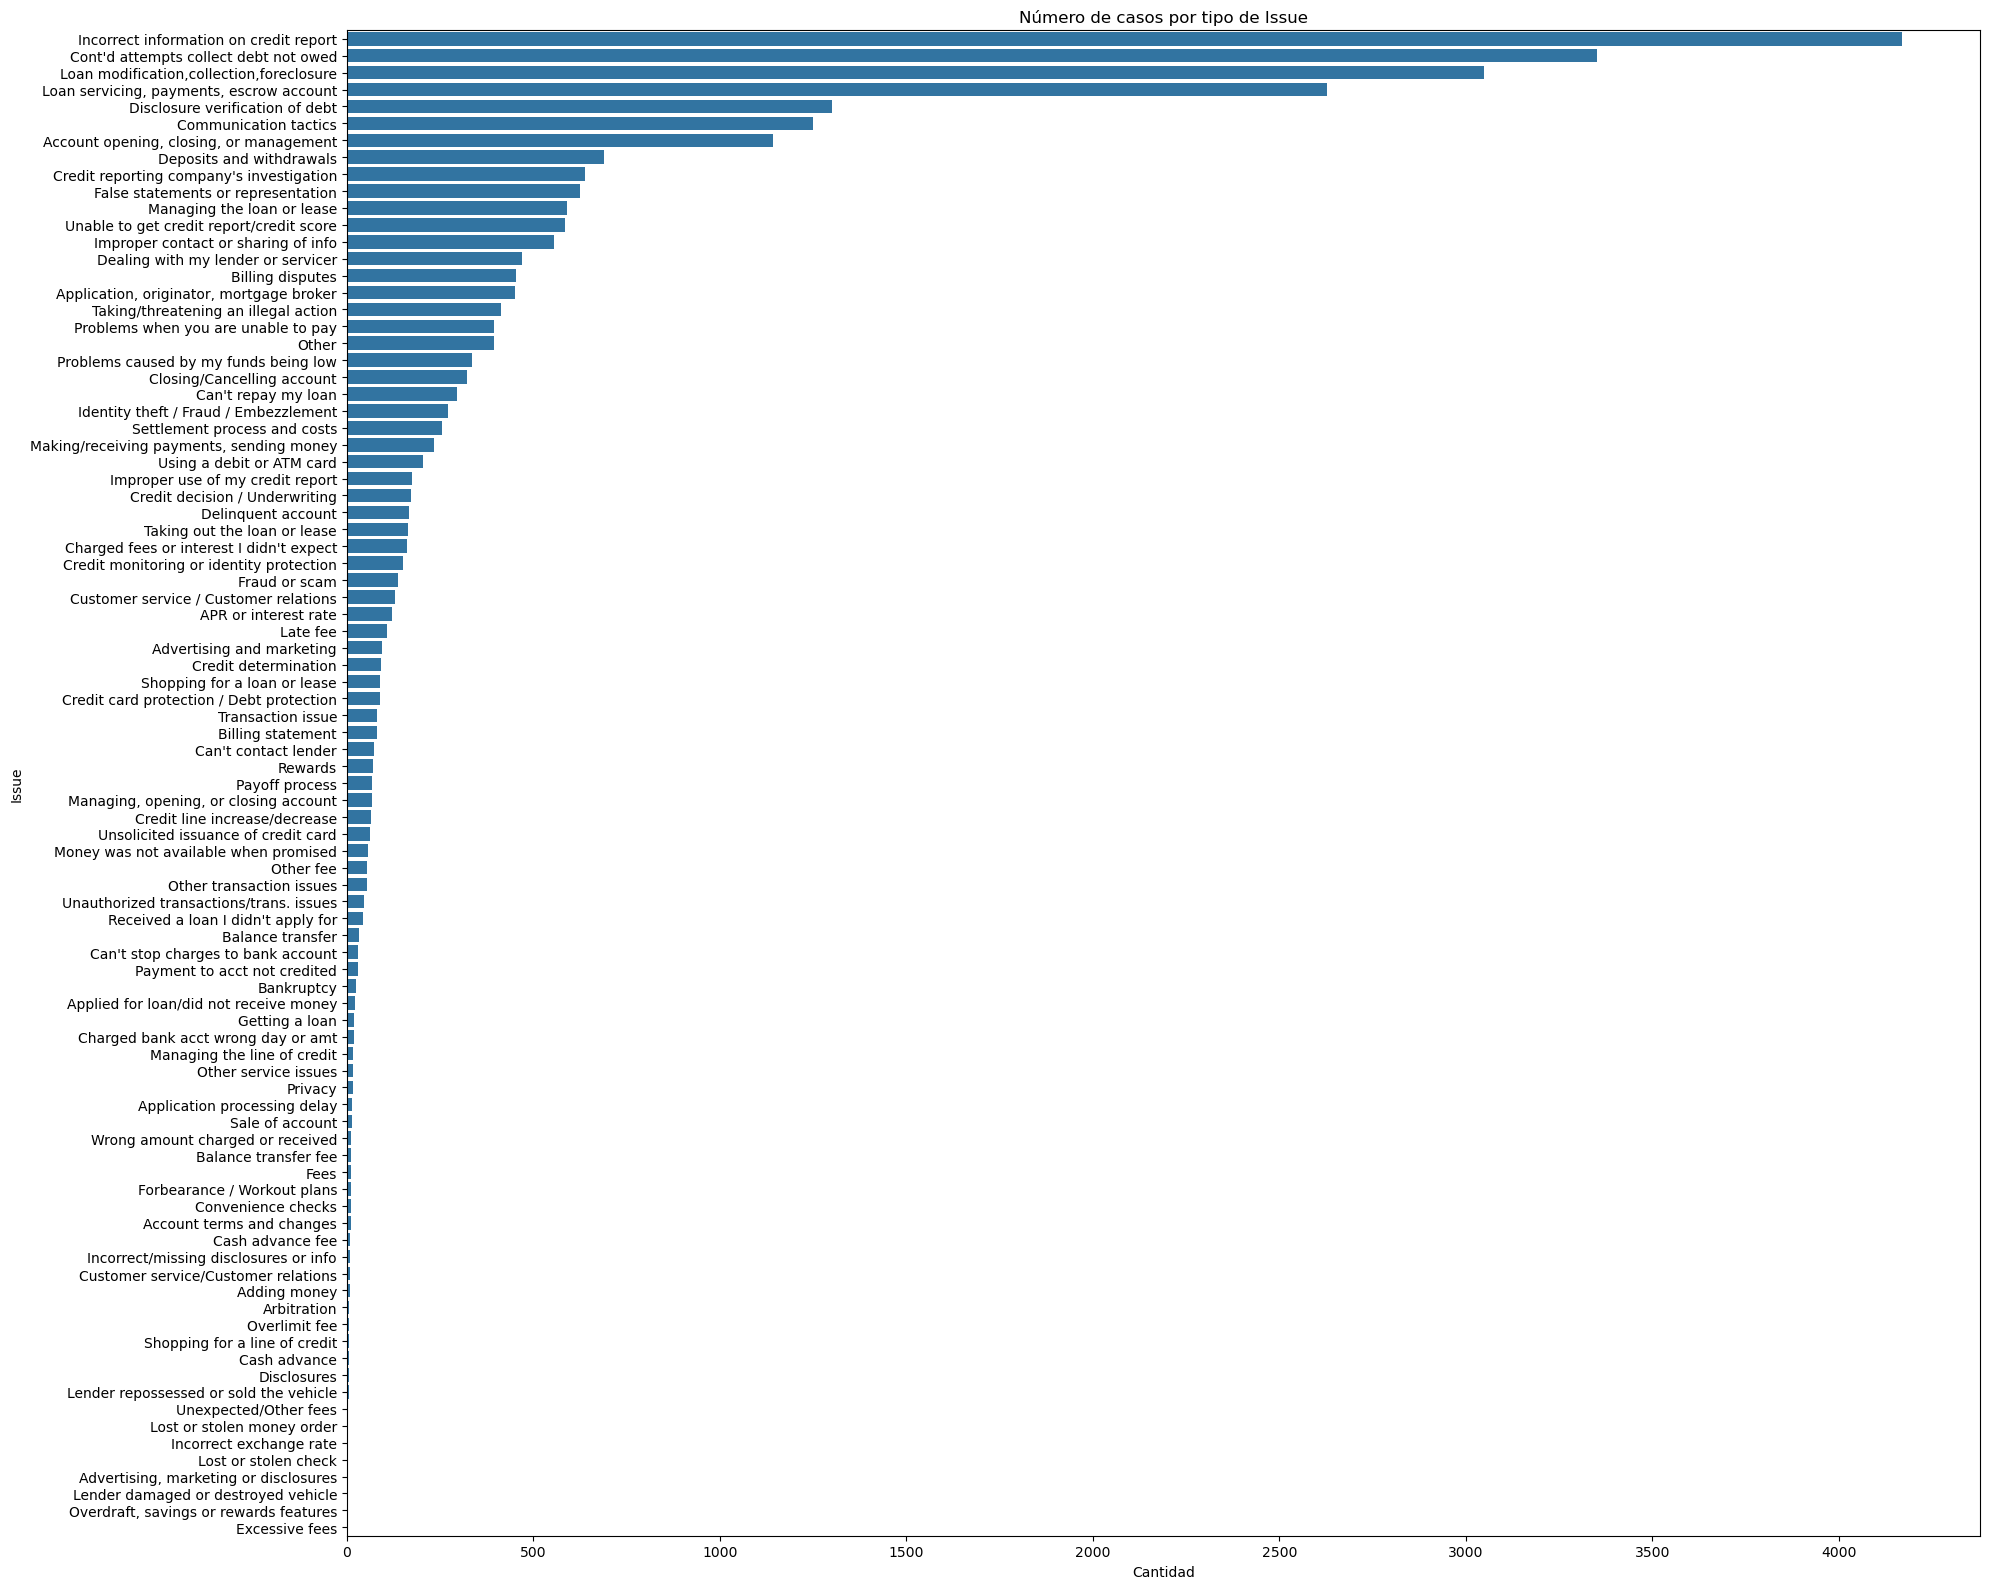

In [185]:
plt.figure(figsize=(20,16))
sns.countplot(y='Issue', data=dt_quejas_corr, order=dt_quejas_corr['Issue'].value_counts().index)
plt.title('Número de casos por tipo de Issue')
plt.xlabel('Cantidad')
plt.ylabel('Issue')
plt.tight_layout()
plt.show()

C:\Users\jonol\AppData\Local\Temp\ipykernel_6080\2564424755.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




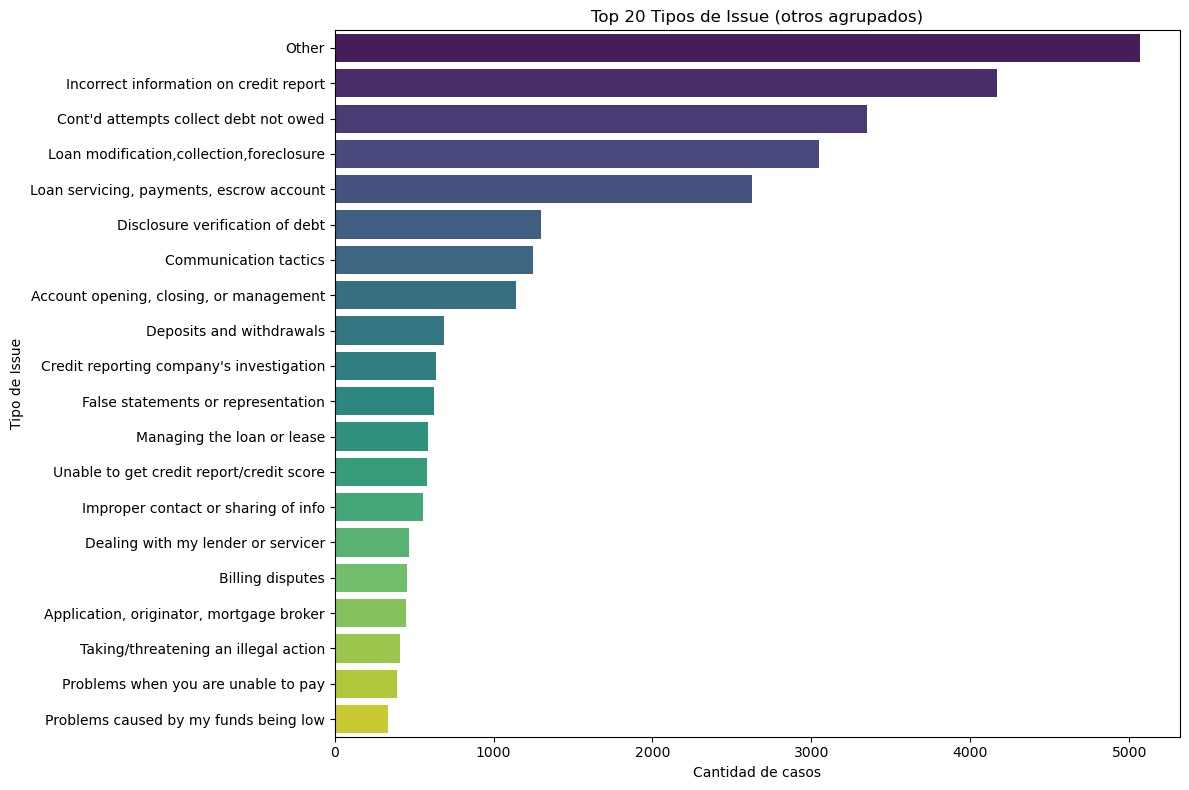

In [186]:
top_20_issues = dt_quejas_corr['Issue'].value_counts().nlargest(20).index
dt_quejas_corr['Issue_top20'] = dt_quejas_corr['Issue'].apply(lambda x: x if x in top_20_issues else 'Other')
issue_order = dt_quejas_corr['Issue_top20'].value_counts().sort_values(ascending=False).index
plt.figure(figsize=(12,8))
sns.countplot(y='Issue_top20', data=dt_quejas_corr, order=issue_order, palette='viridis')
plt.title('Top 20 Tipos de Issue (otros agrupados)')
plt.xlabel('Cantidad de casos')
plt.ylabel('Tipo de Issue')
plt.tight_layout()
plt.show()


In [187]:
list(dt_quejas_corr['Issue'].unique())


['Communication tactics',
 "Cont'd attempts collect debt not owed",
 'Application, originator, mortgage broker',
 'Other',
 'Managing the loan or lease',
 'Taking/threatening an illegal action',
 'False statements or representation',
 'Deposits and withdrawals',
 "Can't contact lender",
 'Disclosure verification of debt',
 'Loan modification,collection,foreclosure',
 'Improper contact or sharing of info',
 'Problems when you are unable to pay',
 'Account opening, closing, or management',
 'Incorrect information on credit report',
 'Loan servicing, payments, escrow account',
 'Other transaction issues',
 "Credit reporting company's investigation",
 'Delinquent account',
 'Late fee',
 'Taking out the loan or lease',
 'Credit decision / Underwriting',
 'Managing the line of credit',
 "Can't stop charges to bank account",
 "Charged fees or interest I didn't expect",
 'Improper use of my credit report',
 'Using a debit or ATM card',
 'Billing statement',
 'Problems caused by my funds being 

C:\Users\jonol\AppData\Local\Temp\ipykernel_6080\898133599.py:70: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




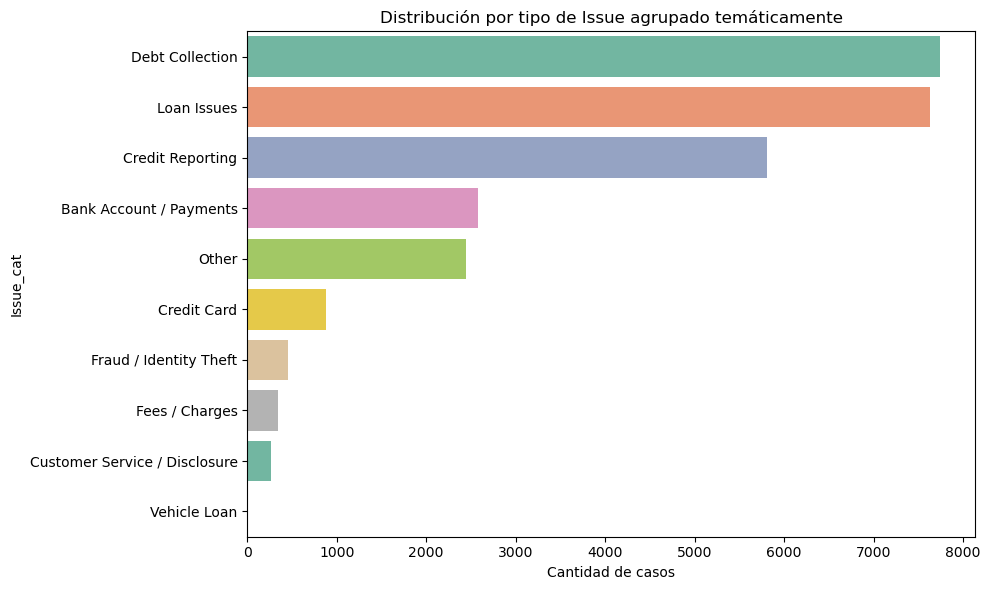

In [188]:
def issue_agrupados(issue):
    issue = issue.lower()
    if issue in [
        'communication tactics', "cont'd attempts collect debt not owed", 'taking/threatening an illegal action',
        'false statements or representation', 'disclosure verification of debt',
        'improper contact or sharing of info', 'settlement process and costs'
    ]:
        return 'Debt Collection'

    elif issue in [
        'loan modification,collection,foreclosure', 'managing the loan or lease', 'loan servicing, payments, escrow account',
        "can't contact lender", "can't repay my loan", 'forbearance / workout plans', 'getting a loan',
        "received a loan i didn't apply for", 'shopping for a loan or lease', 'application, originator, mortgage broker',
        'taking out the loan or lease', 'application processing delay', 'applied for loan/did not receive money',
        'credit decision / underwriting'
    ]:
        return 'Loan Issues'

    elif issue in [
        'incorrect information on credit report', "credit reporting company's investigation",
        'improper use of my credit report', 'unable to get credit report/credit score',
        'credit monitoring or identity protection', 'credit determination'
    ]:
        return 'Credit Reporting'

    elif issue in [
        'deposits and withdrawals', 'account opening, closing, or management',
        'making/receiving payments, sending money', 'payment to acct not credited',
        'charged bank acct wrong day or amt', "can't stop charges to bank account",
        'problems caused by my funds being low', 'account terms and changes',
        'managing, opening, or closing account', 'adding money', 'sale of account'
    ]:
        return 'Bank Account / Payments'

    elif issue in [
        'billing statement', 'billing disputes', 'rewards', 'credit card protection / debt protection',
        'unsolicited issuance of credit card', 'credit line increase/decrease', 'overlimit fee',
        'cash advance', 'balance transfer', 'balance transfer fee'
    ]:
        return 'Credit Card'

    elif issue in [
        "charged fees or interest i didn't expect", 'late fee', 'excessive fees', 'other fee',
        'cash advance fee', 'unexpected/other fees'
    ]:
        return 'Fees / Charges'

    elif issue in [
        'identity theft / fraud / embezzlement', 'fraud or scam', 'unauthorized transactions/trans. issues'
    ]:
        return 'Fraud / Identity Theft'

    elif issue in [
        'customer service / customer relations', 'customer service/customer relations', 'disclosures',
        'incorrect/missing disclosures or info', 'advertising and marketing',
        'advertising, marketing or disclosures', 'privacy'
    ]:
        return 'Customer Service / Disclosure'

    elif issue in [
        'lender repossessed or sold the vehicle', 'lender damaged or destroyed vehicle'
    ]:
        return 'Vehicle Loan'

    else:
        return 'Other'
    
dt_quejas_corr['Issue_cat'] = dt_quejas_corr['Issue'].str.lower().apply(issue_agrupados)
plt.figure(figsize=(10,6))
sns.countplot(y='Issue_cat', data=dt_quejas_corr, order=dt_quejas_corr['Issue_cat'].value_counts().index, palette='Set2')
plt.title('Distribución por tipo de Issue agrupado temáticamente')
plt.xlabel('Cantidad de casos')
plt.tight_layout()
plt.show()



In [189]:
subissue_valores = dt_quejas_corr['Sub-issue'].value_counts()
print(subissue_valores)


Sub-issue
Unknown                                     14945
Debt is not mine                             2125
Account status                               1604
Information is not mine                      1307
Debt was paid                                 890
Not given enough info to verify debt          815
Frequent or repeated calls                    754
Account terms                                 484
Attempted to collect wrong amount             482
Right to dispute notice not received          387
Problem getting my free annual report         386
Public record                                 356
Talked to a third party about my debt         289
Personal information                          258
Threatened to take legal action               246
Problem with statement of dispute             243
No notice of investigation status/result      241
Debt resulted from identity theft             205
Problem getting report or credit score        198
Report improperly shared by CRC         

In [190]:
min_freq = 100
def agrupar_subissues(df, min_freq=100):
    subissue_grouped = []

    for issue in df['Issue_cat'].unique():
        subset = df[df['Issue_cat'] == issue]
        freq = subset['Sub-issue'].value_counts()
        frecuentes = freq[freq >= min_freq].index.tolist()

        # Para cada fila, asignar subissue si frecuente, sino "Other Sub-issue"
        subissue_grouped += df.loc[df['Issue_cat'] == issue, 'Sub-issue'].apply(
            lambda x: x if x in frecuentes else 'Other Sub-issue'
        ).tolist()
    
    df['Sub_issue_agrupado'] = subissue_grouped
    return df

dt_quejas_corr = agrupar_subissues(dt_quejas_corr, min_freq=100)

C:\Users\jonol\AppData\Local\Temp\ipykernel_6080\3497405533.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




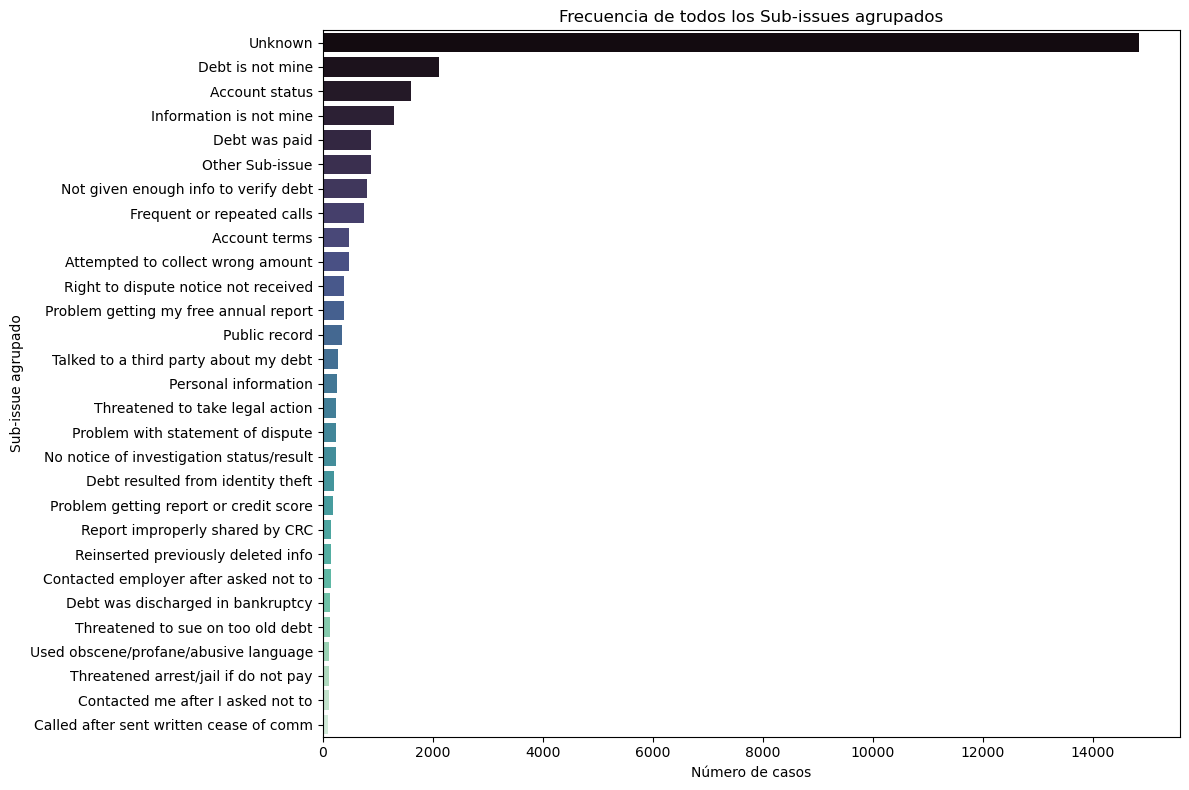

In [191]:
plt.figure(figsize=(12,8))
order = dt_quejas_corr['Sub_issue_agrupado'].value_counts().index
sns.countplot(y='Sub_issue_agrupado', data=dt_quejas_corr, order=order, palette='mako')
plt.title('Frecuencia de todos los Sub-issues agrupados')
plt.xlabel('Número de casos')
plt.ylabel('Sub-issue agrupado')
plt.tight_layout()
plt.show()

C:\Users\jonol\AppData\Local\Temp\ipykernel_6080\1198169961.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




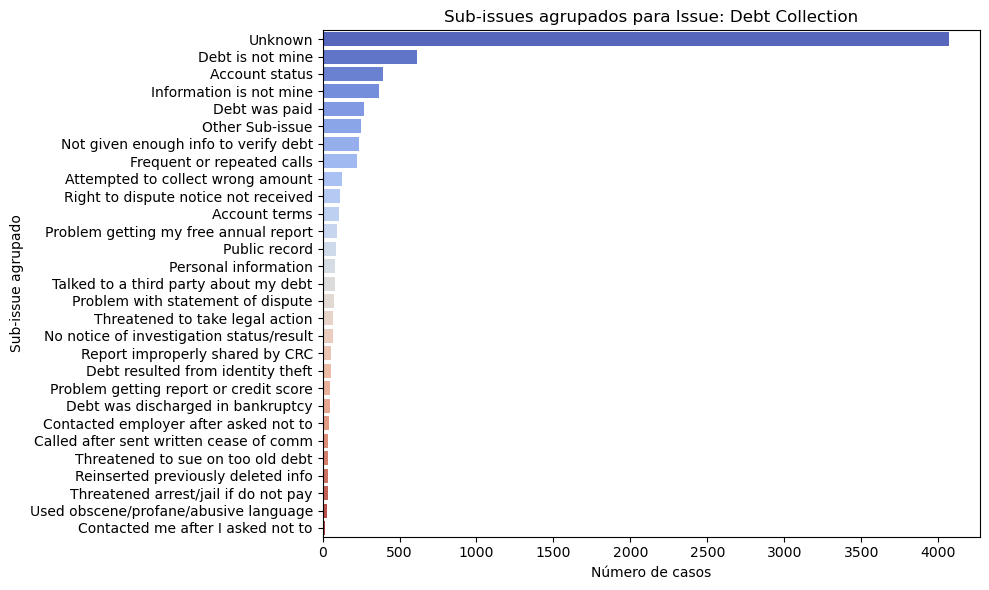

C:\Users\jonol\AppData\Local\Temp\ipykernel_6080\1198169961.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




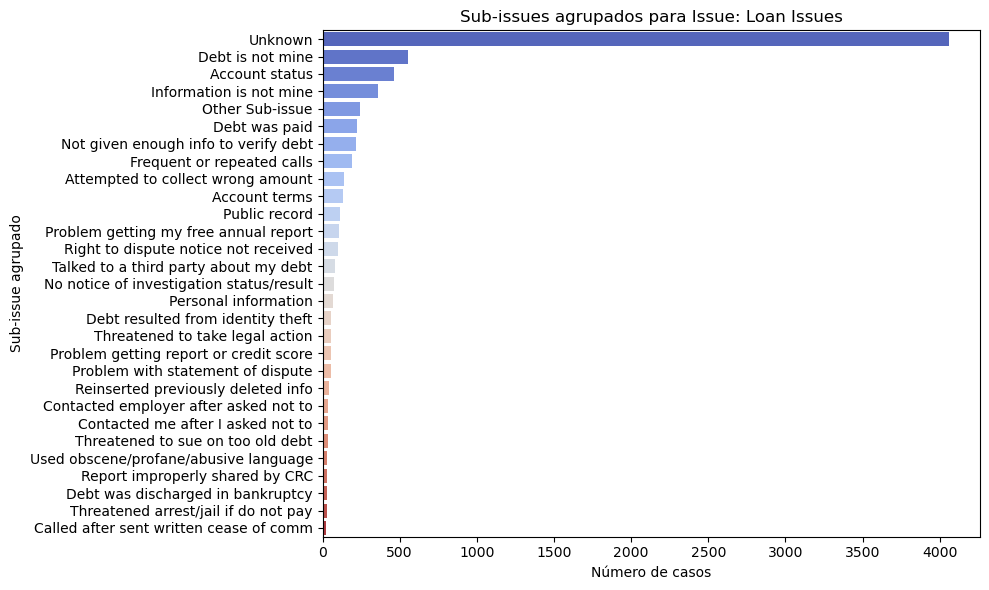

C:\Users\jonol\AppData\Local\Temp\ipykernel_6080\1198169961.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




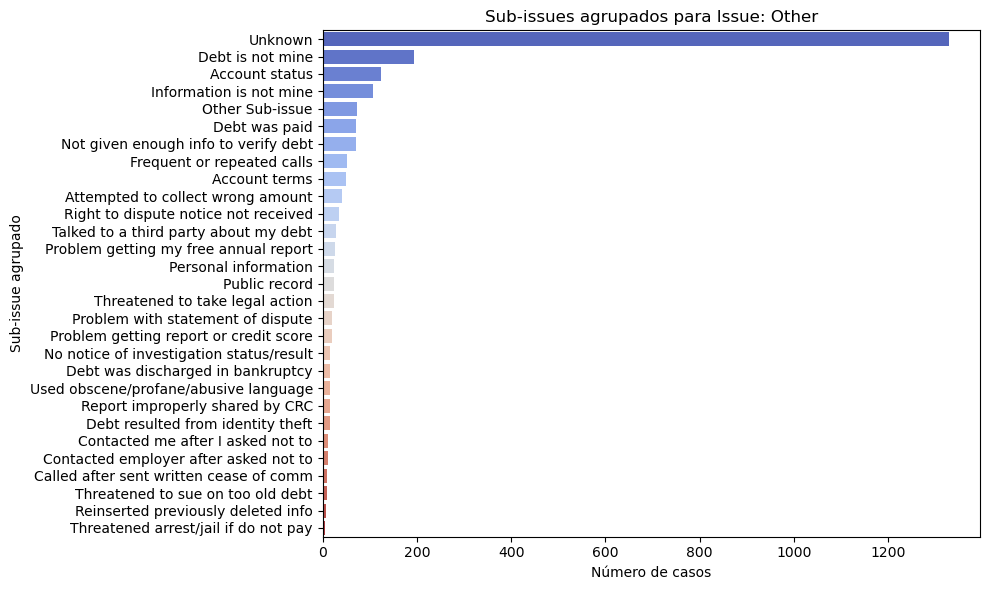

C:\Users\jonol\AppData\Local\Temp\ipykernel_6080\1198169961.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




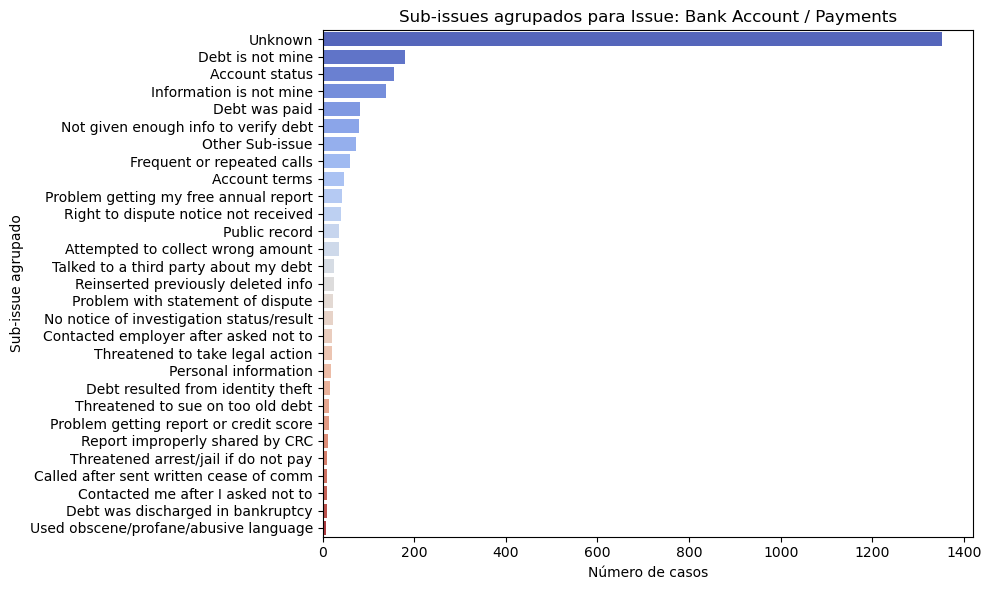

C:\Users\jonol\AppData\Local\Temp\ipykernel_6080\1198169961.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




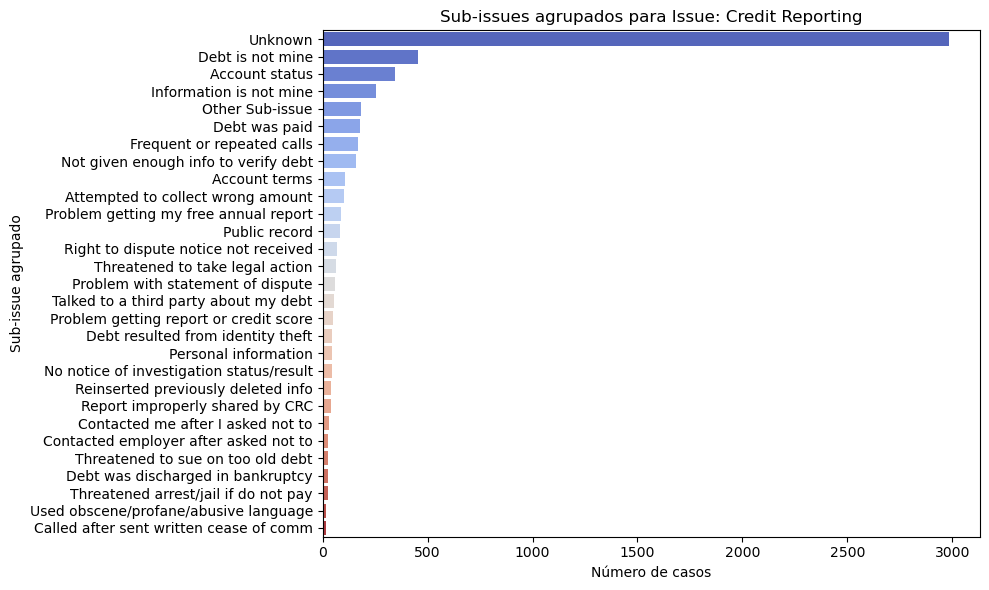

C:\Users\jonol\AppData\Local\Temp\ipykernel_6080\1198169961.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




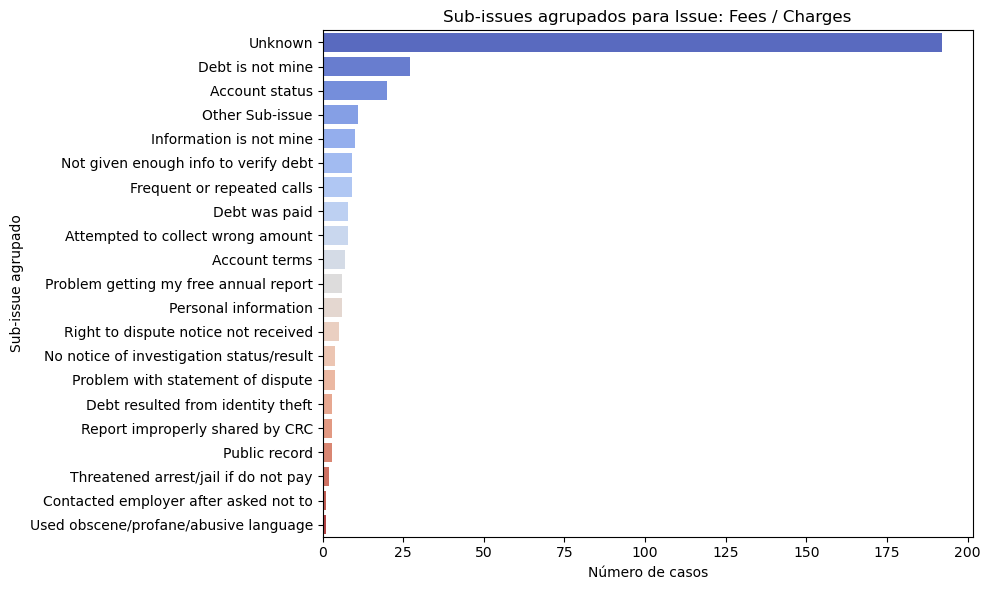

C:\Users\jonol\AppData\Local\Temp\ipykernel_6080\1198169961.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




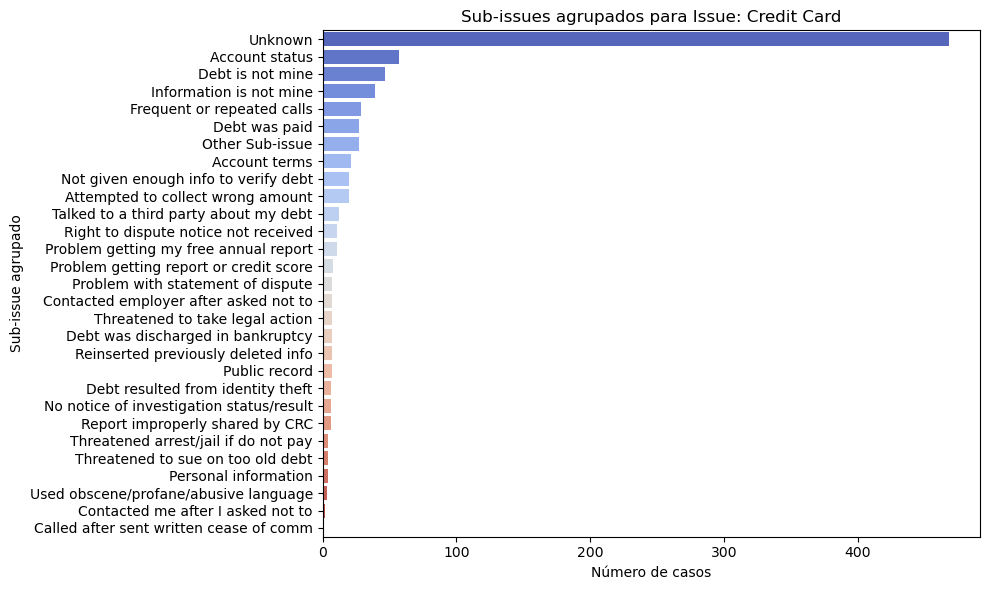

C:\Users\jonol\AppData\Local\Temp\ipykernel_6080\1198169961.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




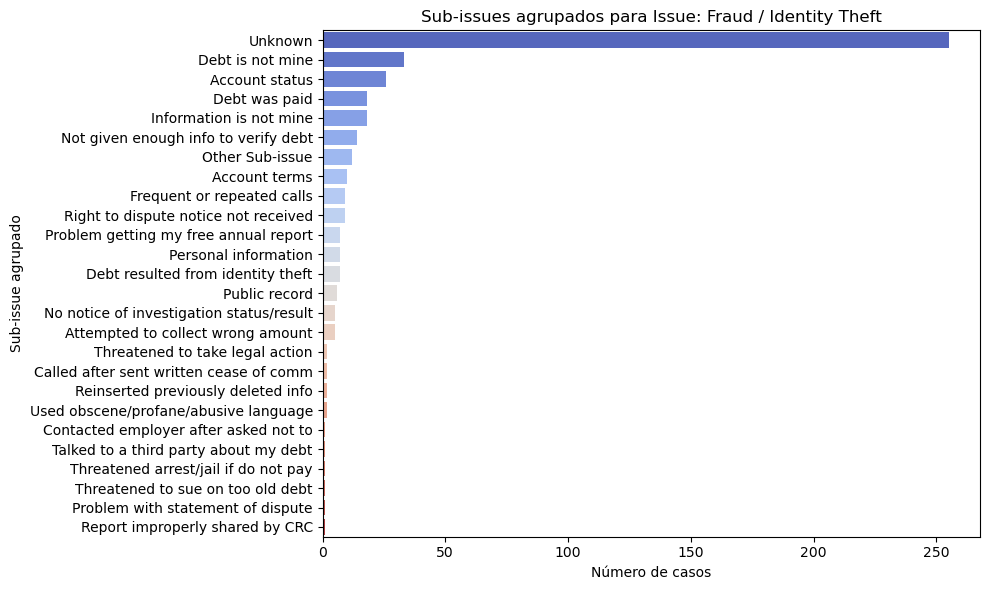

C:\Users\jonol\AppData\Local\Temp\ipykernel_6080\1198169961.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




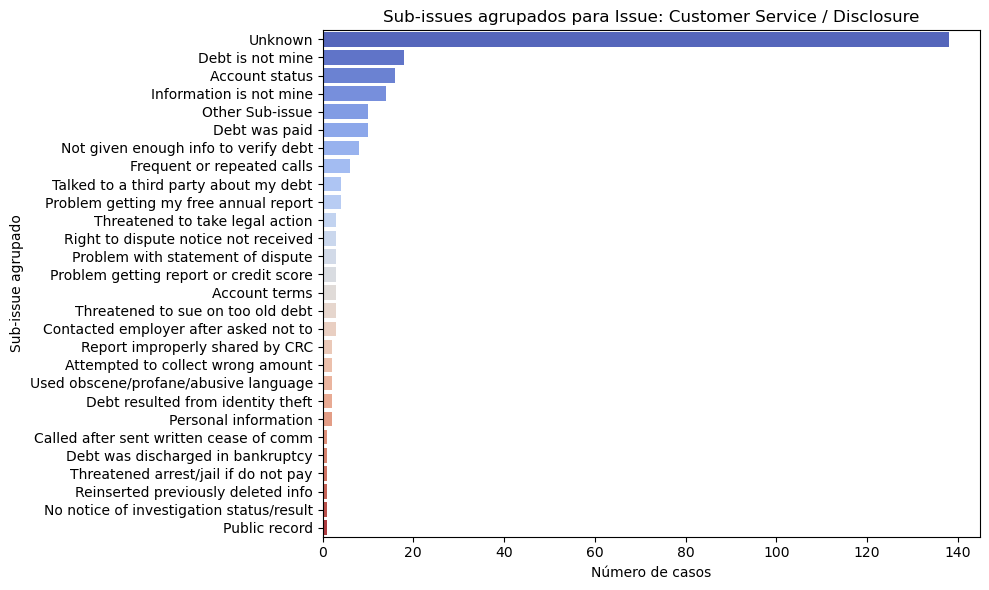

C:\Users\jonol\AppData\Local\Temp\ipykernel_6080\1198169961.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




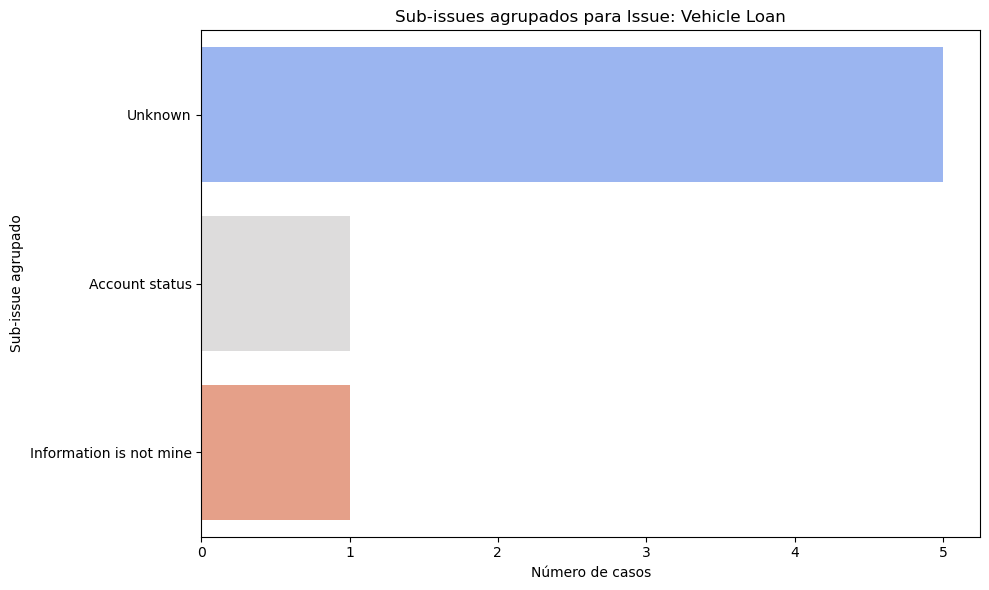

In [192]:
issue_categories = dt_quejas_corr['Issue_cat'].unique()
for issue in issue_categories:
    df_issue = dt_quejas_corr[dt_quejas_corr['Issue_cat'] == issue]
    order = df_issue['Sub_issue_agrupado'].value_counts().index

    plt.figure(figsize=(10,6))
    sns.countplot(y='Sub_issue_agrupado', data=df_issue, order=order, palette='coolwarm')
    plt.title(f'Sub-issues agrupados para Issue: {issue}')
    plt.xlabel('Número de casos')
    plt.ylabel('Sub-issue agrupado')
    plt.tight_layout()
    plt.show()



In [193]:
casos_por_estado = dt_quejas_corr['State'].value_counts().reset_index()
casos_por_estado.columns = ['State', 'Cases']

casos_por_estado = casos_por_estado[casos_por_estado['State'].str.len() == 2]

fig = go.Figure(data=go.Choropleth(
    locations=casos_por_estado['State'],
    z=casos_por_estado['Cases'].astype(float),
    locationmode='USA-states',
    colorscale='Viridis',
    colorbar_title="Número de casos",
))

fig.update_layout(
    title_text='Número de casos por estado (USA)',
    geo=dict(scope='usa', lakecolor='rgb(255, 255, 255)'),
)

fig.show()




In [194]:
casos_por_estado_pref = dt_quejas_corr['State_pref'].value_counts().reset_index()
casos_por_estado_pref.columns = ['State_pref', 'Cases']

casos_por_estado_pref = casos_por_estado_pref[casos_por_estado_pref['State_pref'].str.len() == 2]

fig = go.Figure(data=go.Choropleth(
    locations=casos_por_estado_pref['State_pref'],
    z=casos_por_estado_pref['Cases'].astype(float),
    locationmode='USA-states',
    colorscale='Viridis',
    colorbar_title="Número de casos",
))

fig.update_layout(
    title_text='Número de casos por estado (USA)',
    geo=dict(scope='usa', lakecolor='rgb(255, 255, 255)'),
)

fig.show()